# 05: Beyond equilibrium: exploiting tilt (and a pre-registration that caught a false positive)

A Nash strategy is *provably* over-conservative against a suboptimal opponent: it guarantees you don't lose, but doesn't actively punish mistakes (SES, NeurIPS 2022; `docs/V2_RESEARCH_ROADMAP.md`). The one direction with a realistic *positive* result is therefore **exploitation**: detect an opponent's leak and deviate to attack it. This project already has the detector, a two-state {normal, tilted} HMM that tracks `P(opponent tilted)`, and a genuinely tilting opponent. This notebook reproduces the pre-registered EV test of turning that signal into a policy.

The hypothesis: a **DBR-style knob** (Johanson & Bowling 2009) that conditions the policy on `p_tilted` (*call lighter, value-bet thinner* as tilt rises; `p_tilted=0` recovers the baseline), and earns EV over a non-exploiting baseline against the tilter.

**The result is the most instructive in the project, and not the one I expected.** It is a *resolved negative*, and the story of how a tempting, small-sample-supported edge did **not** survive a powered, pre-registered test is exactly the quant lesson the whole repo is built around.

In [1]:
import os, sys, json
ROOT = os.getcwd()
while not (os.path.isdir(os.path.join(ROOT, "results"))
          and os.path.isdir(os.path.join(ROOT, "src"))) \
        and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from IPython.display import Image, display

def load(name):
    with open(os.path.join(ROOT, "results", name)) as f:
        return json.load(f)

def fig(name):
    display(Image(filename=os.path.join(ROOT, "figures", name)))
print("repo root resolved:", os.path.basename(ROOT))

repo root resolved: poker-simulation


## 1. The knob and the clean comparison (§13)

`BotPlayer(tilt_exploit=True)` sets `eff_tight = tight − 0.15·p_tilted` (call lighter) and `eff_aggr = aggr + 0.25·p_tilted` (value-bet thinner); the slopes are a-priori, frozen before any EV was measured (`PREREGISTRATION.md` §13). The **exploiter** and the **non-exploiter** are byte-identical except this one knob: both carry the *same* live HMM detector and both use vanilla equity, so the only thing that varies is whether the policy *acts* on the detected tilt. Both play the same fixed `AdaptiveBotPlayer("tilt")` on the same paired, mirror + all-in-EV seed block.

## 2. The pre-registered result: re-derived from the committed per-seed deltas

We recompute the primary metric (the per-seed paired delta `exploiter − non-exploiter`) with the project's own `bootstrap_ci` and exact `binomial_sign_test`, and read off the pre-committed verdict (§13.3: positive iff the 95% CI excludes 0 above, negative iff below, else null).

In [2]:
from src.stats import bootstrap_ci, binomial_sign_test
d = load("exploitation.json")
p = d["primary"]; delta = p["per_seed_delta"]
ci = bootstrap_ci(delta); st = binomial_sign_test(delta)
print(f"PRIMARY vs the fixed tilter ({len(delta)} paired seeds, mirror + all-in-EV):")
print(f"  non-exploiter (baseline)      edge : {p['baseline_edge_vs_opp']:+.0f} chips/match")
print(f"  exploiter (tilt knob on)      edge : {p['exploiter_edge_vs_opp']:+.0f} chips/match")
print(f"  paired delta (exploiter - baseline): {ci['mean']:+.0f}  95% CI [{ci['lo']:+.0f}, {ci['hi']:+.0f}]")
print(f"  exact binomial sign test: {st['wins']}W-{st['losses']}L-{st['ties']}T  p = {st['p_value']:.3f}")
verdict = ("POSITIVE" if ci["lo"] > 0 else ("NEGATIVE" if ci["hi"] < 0 else "null / unresolved"))
print(f"  -> pre-committed verdict (§13.3): exploitation edge {verdict}")
c = d["control_non_tilter"]; cci = c["paired_delta_ci95"]
print(f"\nCONTROL vs a non-tilting station (exploratory): {cci['mean']:+.0f} "
      f"[{cci['lo']:+.0f}, {cci['hi']:+.0f}] -> "
      f"{'resolved' if (cci['lo']>0 or cci['hi']<0) else 'within noise (unresolved)'}")

PRIMARY vs the fixed tilter (300 paired seeds, mirror + all-in-EV):
  non-exploiter (baseline)      edge : +533 chips/match
  exploiter (tilt knob on)      edge : +196 chips/match
  paired delta (exploiter - baseline): -169  95% CI [-271, -66]
  exact binomial sign test: 131W-168L-1T  p = 0.037
  -> pre-committed verdict (§13.3): exploitation edge NEGATIVE

CONTROL vs a non-tilting station (exploratory): -13 [-81, +55] -> within noise (unresolved)


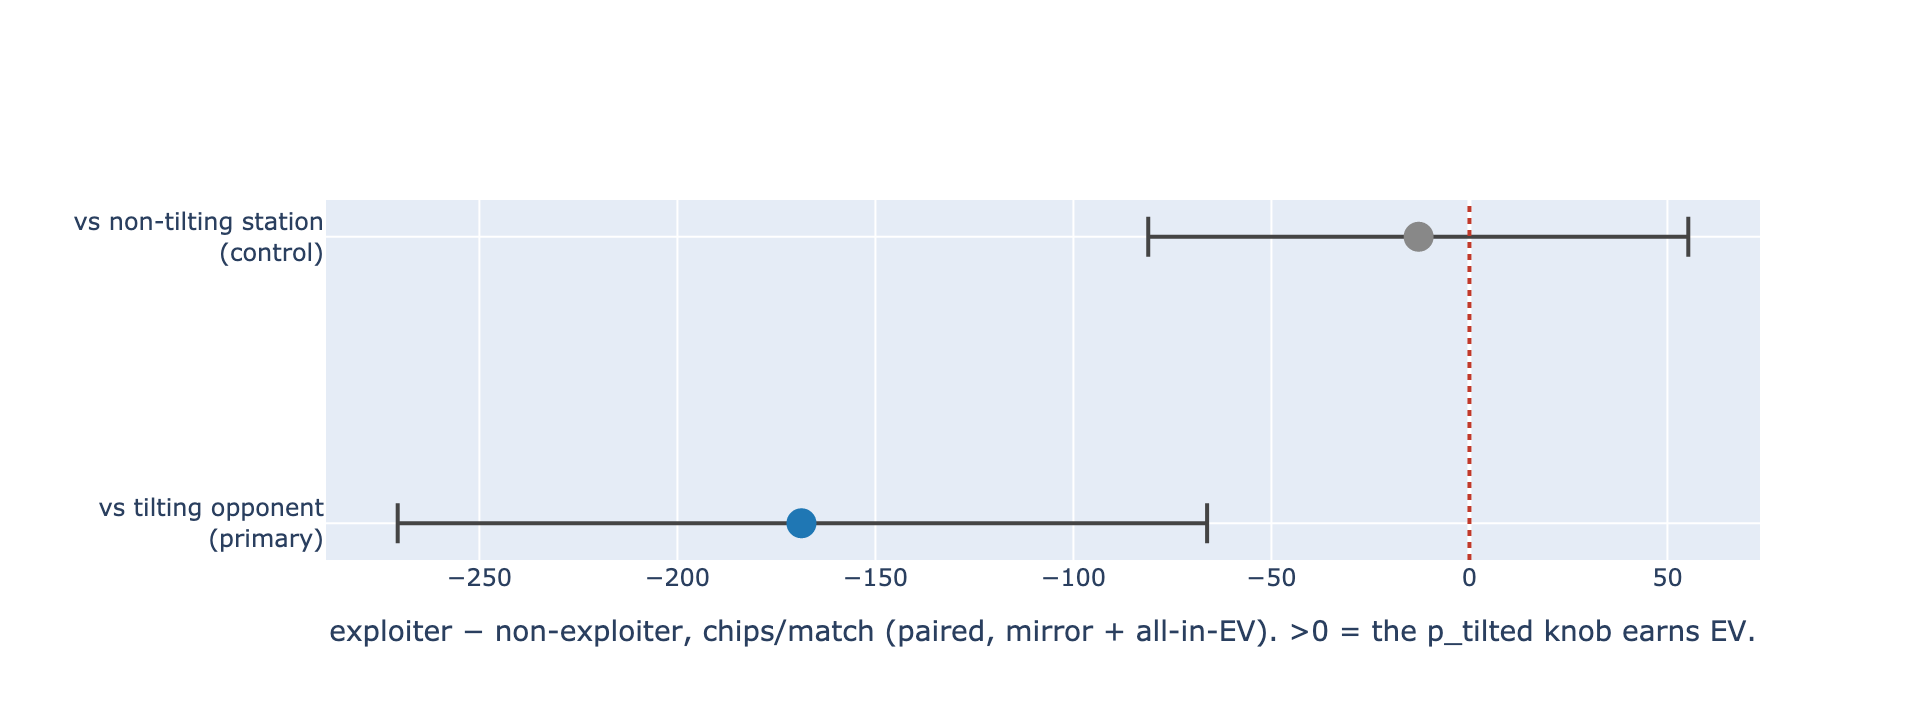

In [3]:
fig("exploitation.png")

## 3. Why the textbook counter-policy backfired, and why that is a *good* result

**The mechanism.** The disciplined baseline *already* crushes the tilter (+533 chips/match): a tight-ish value-bettor punishes a loose-aggressive opponent by betting for value and folding marginal spots. "Call lighter / value-bet thinner" is the right counter to an opponent that *over-bluffs*, but this tilter is a loose-aggressive **maniac** (plays ~any hand and raises ~always when tilted), so calling lighter pays off its *value* and value-betting thinner walks into its re-raises. Against a maniac the correct adjustment is to **tighten and trap**, not loosen. The control confirms the mechanism: the same knob is ~neutral vs a *passive* station (which doesn't punish loosening) but loses vs the *aggressive* tilter. This is the **exploitation-vs-exploitability tradeoff** made concrete: a deviation tuned for one opponent archetype is counter-exploited by another.

**The discipline win (the real point).** An exploratory `n=6` smoke check (run only to confirm the script executed, and explicitly *not* used to set the frozen config) happened to show a **+152** paired delta. The pre-registered, properly-powered `n=300` run **overturned it to −169**. The small-sample peek was noise. Reporting the powered, pre-committed result over the tempting peek, and *not* flipping the knob's sign post-hoc and re-running until it "works": that is exactly what pre-registration is for. In a trading backtest this is the difference between a strategy that looks great on 6 days and bleeds over 300.

### Honest takeaway

The pre-registered test resolves a **negative**: conditioning the policy on detected tilt via this a-priori DBR-style counter-policy **reduces** EV against this loose-aggressive tilter (−169 chips/match, 95% CI [−271, −66], sign-test p≈0.04) relative to a disciplined non-exploiting baseline, because the baseline already exploits the tilter, and loosening walks into its aggression. Measured vs **this** opponent only; no Nash-safety claim is made or implied (an exploiter is itself counter-exploitable).

This is the fourth honest v2 negative, and the most transferable: a textbook-motivated, small-sample-supported edge **did not survive** a powered pre-registered test. The deliverable across this whole repo is that discipline: paired/mirror seeding, control variates, the right significance test, and a freeze→result gap that holds even when the result is the opposite of the hypothesis. See `PREREGISTRATION.md` §13 and `docs/V2_RESEARCH_ROADMAP.md`.